In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ustawienia wykresów
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 18

In [2]:
# -----------------------------------------------------------------------------
# 1. ZAŁADOWANIE DANYCH
# -----------------------------------------------------------------------------

iris = load_iris()
X = iris.data                    # 150 próbek × 4 cechy
y = iris.target                  # 3 gatunki (0, 1, 2)
nazwy_cech = ['Długość działki', 'Szerokość działki', 
              'Długość płatka', 'Szerokość płatka']
nazwy_gatunkow = ['Setosa', 'Versicolor', 'Virginica']

print(f"\nWymiary danych: {X.shape[0]} próbek × {X.shape[1]} cechy")
print(f"Cechy: {nazwy_cech}")
print(f"Gatunki: {nazwy_gatunkow}")


Wymiary danych: 150 próbek × 4 cechy
Cechy: ['Długość działki', 'Szerokość działki', 'Długość płatka', 'Szerokość płatka']
Gatunki: ['Setosa', 'Versicolor', 'Virginica']


In [3]:
print(f"\nWymiary danych: {X.shape[0]} próbek × {X.shape[1]} cechy")
print(f"Cechy: {nazwy_cech}")
print(f"Gatunki: {nazwy_gatunkow}")


Wymiary danych: 150 próbek × 4 cechy
Cechy: ['Długość działki', 'Szerokość działki', 'Długość płatka', 'Szerokość płatka']
Gatunki: ['Setosa', 'Versicolor', 'Virginica']


In [4]:
# -----------------------------------------------------------------------------
# 2. STANDARYZACJA DANYCH (WAŻNE!)
# -----------------------------------------------------------------------------
# PCA jest wrażliwe na skalę - zmienne o większej wariancji dominują!
# Dlatego ZAWSZE standaryzujemy dane przed PCA

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("\n" + "-" * 60)
print("STANDARYZACJA (mean=0, std=1)")
print("-" * 60)
print(f"Przed: średnie = {X.mean(axis=0).round(2)}")
print(f"Po:    średnie = {X_std.mean(axis=0).round(2)}")



------------------------------------------------------------
STANDARYZACJA (mean=0, std=1)
------------------------------------------------------------
Przed: średnie = [5.84 3.06 3.76 1.2 ]
Po:    średnie = [-0. -0. -0. -0.]


In [5]:
# -----------------------------------------------------------------------------
# 3. WYKONANIE PCA
# -----------------------------------------------------------------------------

pca = PCA()  # Wszystkie składowe (domyślnie n_components = min(n_samples, n_features))
X_pca = pca.fit_transform(X_std)

print("\n" + "-" * 60)
print("WYNIKI PCA")
print("-" * 60)

# Wartości własne (eigenvalues) - pokazują "siłę" każdej składowej
print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.3f}")

# Procent wyjaśnionej wariancji - kluczowa metryka!
print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

# Skumulowana wariancja - ile łącznie wyjaśniają składowe
print(f"\nSkumulowana wariancja:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cs in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cs*100:.1f}%")

print("\n→ Wniosek: PC1 + PC2 wyjaśniają", f"{cumsum[1]*100:.1f}% wariancji!")
print("→ Można zredukować 4D → 2D z minimalną stratą informacji")


------------------------------------------------------------
WYNIKI PCA
------------------------------------------------------------

Wartości własne (eigenvalues):
  PC1: 2.938
  PC2: 0.920
  PC3: 0.148
  PC4: 0.021

Wyjaśniona wariancja (%):
  PC1: 73.0%
  PC2: 22.9%
  PC3: 3.7%
  PC4: 0.5%

Skumulowana wariancja:
  PC1-PC1: 73.0%
  PC1-PC2: 95.8%
  PC1-PC3: 99.5%
  PC1-PC4: 100.0%

→ Wniosek: PC1 + PC2 wyjaśniają 95.8% wariancji!
→ Można zredukować 4D → 2D z minimalną stratą informacji


In [6]:
# -----------------------------------------------------------------------------
# 4. ŁADUNKI (LOADINGS) - interpretacja składowych
# -----------------------------------------------------------------------------
print("\n" + "-" * 60)
print("ŁADUNKI SKŁADOWYCH (LOADINGS)")
print("-" * 60)
print("\nJak oryginalne cechy wpływają na główne składowe:\n")
print(f"{'Cecha':<20} {'PC1':>8} {'PC2':>8} {'PC3':>8} {'PC4':>8}")
print("-" * 50)
for i, nazwa in enumerate(nazwy_cech):
    loadings = pca.components_[:, i]
    print(f"{nazwa:<20} {loadings[0]:>8.3f} {loadings[1]:>8.3f} {loadings[2]:>8.3f} {loadings[3]:>8.3f}")

print("\n→ PC1: głównie długość i szerokość płatka (rozmiar płatka)")
print("→ PC2: głównie szerokość działki")


------------------------------------------------------------
ŁADUNKI SKŁADOWYCH (LOADINGS)
------------------------------------------------------------

Jak oryginalne cechy wpływają na główne składowe:

Cecha                     PC1      PC2      PC3      PC4
--------------------------------------------------
Długość działki         0.521    0.377    0.720   -0.261
Szerokość działki      -0.269    0.923   -0.244    0.124
Długość płatka          0.580    0.024   -0.142    0.801
Szerokość płatka        0.565    0.067   -0.634   -0.524

→ PC1: głównie długość i szerokość płatka (rozmiar płatka)
→ PC2: głównie szerokość działki


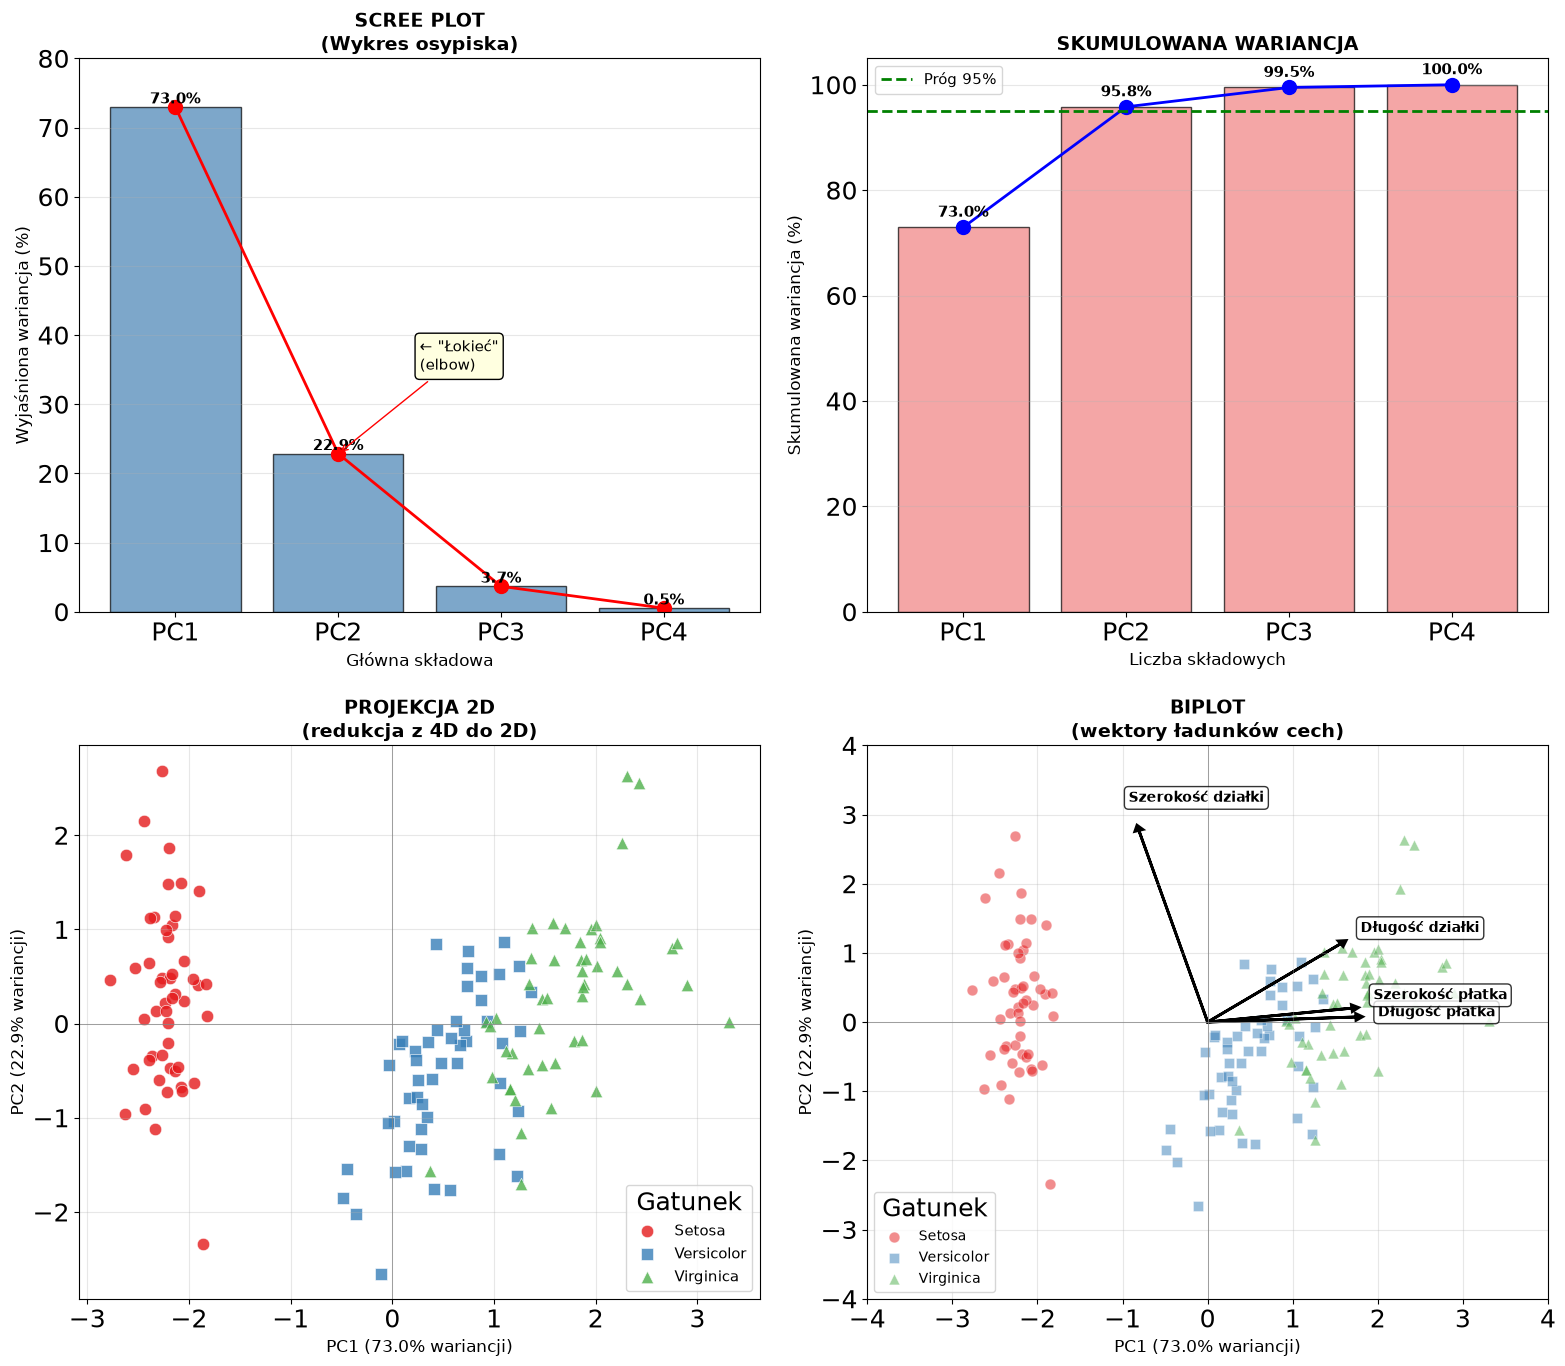

In [7]:
# -----------------------------------------------------------------------------
# 5. WIZUALIZACJE
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- Wykres 1: Scree Plot ---
ax1 = axes[0, 0]
pc_labels = ['PC1', 'PC2', 'PC3', 'PC4']
variance_pct = pca.explained_variance_ratio_ * 100

bars = ax1.bar(pc_labels, variance_pct, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=10, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=12)
ax1.set_xlabel('Główna składowa', fontsize=12)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 80)

# Adnotacje na słupkach
for bar, pct in zip(bars, variance_pct):
    ax1.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Zaznaczenie "łokcia"
ax1.annotate('← "Łokieć"\n(elbow)', xy=(1, variance_pct[1]), xytext=(1.5, 35),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)

# --- Wykres 2: Skumulowana wariancja ---
ax2 = axes[0, 1]
cumulative = np.cumsum(variance_pct)
ax2.bar(pc_labels, cumulative, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.plot(pc_labels, cumulative, 'bo-', markersize=10, linewidth=2)
ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, label='Próg 95%')
ax2.set_ylabel('Skumulowana wariancja (%)', fontsize=12)
ax2.set_xlabel('Liczba składowych', fontsize=12)
ax2.set_title('SKUMULOWANA WARIANCJA', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=11)

for i, pct in enumerate(cumulative):
    ax2.annotate(f'{pct:.1f}%', xy=(i, pct + 2), ha='center', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Wykres 3: Projekcja 2D (PC1 vs PC2) ---
ax3 = axes[1, 0]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=kolor, marker=marker, s=80, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.8)

ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax3.set_title('PROJEKCJA 2D\n(redukcja z 4D do 2D)', fontsize=14, fontweight='bold')
ax3.legend(title='Gatunek', fontsize=11)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# --- Wykres 4: Biplot (wektory cech) ---
ax4 = axes[1, 1]

# Punkty danych
for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=kolor, marker=marker, s=60, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.5)

# Wektory cech (loadings) - pokazują kierunek i siłę wpływu każdej cechy
scale = 3  # skalowanie wektorów dla widoczności
for i, nazwa in enumerate(nazwy_cech):
    if i == 3:
        ax4.arrow(0, 0, 
              pca.components_[0, i] * scale, 
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15, 
             pca.components_[1, i] * scale * 1.65,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else: 
        ax4.arrow(0, 0, 
              pca.components_[0, i] * scale, 
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15, 
             pca.components_[1, i] * scale * 1.15,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


ax4.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax4.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax4.set_title('BIPLOT\n(wektory ładunków cech)', fontsize=14, fontweight='bold')
ax4.legend(title='Gatunek', fontsize=10, loc='lower left')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax4.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_xlim(-4, 4)
ax4.set_ylim(-4, 4)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_iris_demo.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# -----------------------------------------------------------------------------
# 6. BONUS: PCA z redukcją do 2 składowych
# -----------------------------------------------------------------------------
print("\n" + "-" * 60)
print("BONUS: Użycie PCA do redukcji wymiarów")
print("-" * 60)

# Możemy też od razu zdefiniować liczbę składowych
pca_2d = PCA(n_components=2)
X_reduced = pca_2d.fit_transform(X_std)

print(f"\nOryginalne wymiary: {X_std.shape}")
print(f"Po redukcji PCA:    {X_reduced.shape}")
print(f"\nZachowana wariancja: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")



------------------------------------------------------------
BONUS: Użycie PCA do redukcji wymiarów
------------------------------------------------------------

Oryginalne wymiary: (150, 4)
Po redukcji PCA:    (150, 2)

Zachowana wariancja: 95.8%


<Axes: >

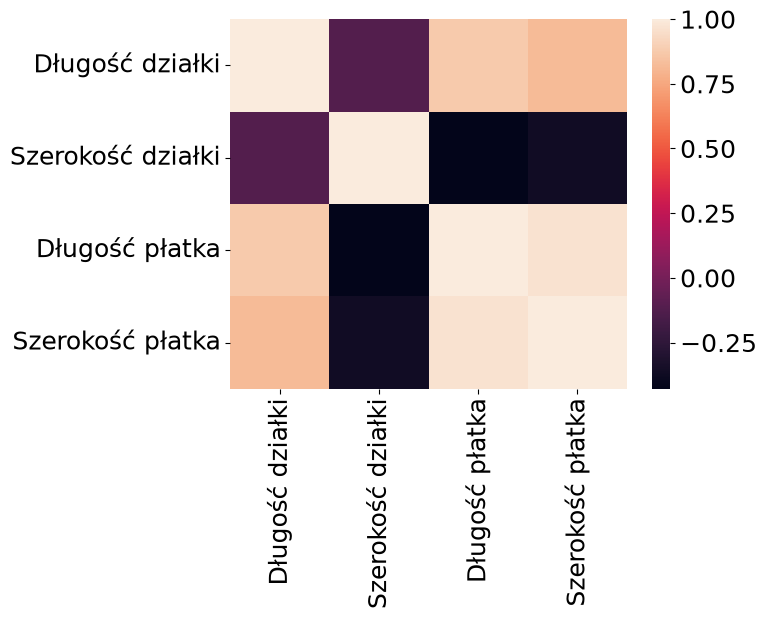

In [9]:
df = pd.DataFrame(X, columns=nazwy_cech)
corr = df.corr()
sns.heatmap(corr)

# ✅ Zadanie: PCA — Zbiór Wine

Zastosowanie PCA do zbioru **Wine** (178 próbek, 13 cech, 3 klasy) w celu redukcji
wymiarowości i analizy struktury danych.

## Część 1 — Przygotowanie danych
## Część 2 — Wykonanie PCA

In [10]:
# Część 1 — załadowanie danych, opis, standaryzacja
from sklearn.datasets import load_wine

wine = load_wine()
Xw = wine.data
yw = wine.target
cechy_pl = ['Alkohol', 'Kwas jabłkowy', 'Popiół', 'Zasadowość popiołu', 'Magnez',
            'Fenole całkowite', 'Flawonoidy', 'Fenole nieflaw.', 'Proantocyjaniny',
            'Intensywność barwy', 'Odcień', 'OD280/OD315', 'Prolina']
klasy = list(wine.target_names)

print("Liczba próbek × cech:", Xw.shape)
print("Nazwy cech:", cechy_pl)
print("Rozkład klas:", dict(zip(klasy, np.bincount(yw).tolist())))

# 1.3 Standaryzacja — cechy mają skrajnie różne skale:
print("\nŚrednia i odchylenie każdej cechy PRZED standaryzacją:")
print(pd.DataFrame({'średnia': Xw.mean(axis=0).round(2),
                    'std': Xw.std(axis=0).round(2)}, index=cechy_pl))

scaler = StandardScaler()
Xw_std = scaler.fit_transform(Xw)
print("\nPo standaryzacji: średnie ≈", Xw_std.mean(axis=0).round(2)[:4], "...",
      "| std ≈", Xw_std.std(axis=0).round(2)[:4], "...")
print("\n→ 'Prolina' ma średnią ~746 i std ~314, a 'Odcień' ~0.96. Bez standaryzacji")
print("  Prolina (przez samą skalę) zdominowałaby PC1. Standaryzacja wyrównuje wpływ cech.")

Liczba próbek × cech: (178, 13)
Nazwy cech: ['Alkohol', 'Kwas jabłkowy', 'Popiół', 'Zasadowość popiołu', 'Magnez', 'Fenole całkowite', 'Flawonoidy', 'Fenole nieflaw.', 'Proantocyjaniny', 'Intensywność barwy', 'Odcień', 'OD280/OD315', 'Prolina']
Rozkład klas: {np.str_('class_0'): 59, np.str_('class_1'): 71, np.str_('class_2'): 48}

Średnia i odchylenie każdej cechy PRZED standaryzacją:
                    średnia     std
Alkohol               13.00    0.81
Kwas jabłkowy          2.34    1.11
Popiół                 2.37    0.27
Zasadowość popiołu    19.49    3.33
Magnez                99.74   14.24
Fenole całkowite       2.30    0.62
Flawonoidy             2.03    1.00
Fenole nieflaw.        0.36    0.12
Proantocyjaniny        1.59    0.57
Intensywność barwy     5.06    2.31
Odcień                 0.96    0.23
OD280/OD315            2.61    0.71
Prolina              746.89  314.02

Po standaryzacji: średnie ≈ [ 0.  0. -0. -0.] ... | std ≈ [1. 1. 1. 1.] ...

→ 'Prolina' ma średnią ~746 i 

In [11]:
# Część 2 — PCA (wszystkie składowe): wartości własne, % i skumulowana wariancja
pca = PCA()
Xw_pca = pca.fit_transform(Xw_std)

war = pca.explained_variance_ratio_ * 100
cum = np.cumsum(war)
tab = pd.DataFrame({
    'wartość_własna': pca.explained_variance_.round(3),
    'wariancja_%': war.round(1),
    'skumulowana_%': cum.round(1),
}, index=[f'PC{i+1}' for i in range(len(war))])
display(tab)

# 2.3 Ile składowych dla >= 80% wariancji?
n80 = int(np.argmax(cum >= 80) + 1)
print(f"Dla ≥80% wariancji potrzeba {n80} składowych (skumulowana = {cum[n80-1]:.1f}%).")
print(f"PC1+PC2 wyjaśniają {cum[1]:.1f}% wariancji.")

,wartość_własna,wariancja_%,skumulowana_%
PC1,4.732,36.2,36.2
PC2,2.511,19.2,55.4
PC3,1.454,11.1,66.5
PC4,0.924,7.1,73.6
PC5,0.858,6.6,80.2
PC6,0.645,4.9,85.1
PC7,0.554,4.2,89.3
PC8,0.350,2.7,92.0
PC9,0.291,2.2,94.2
PC10,0.252,1.9,96.2


Dla ≥80% wariancji potrzeba 5 składowych (skumulowana = 80.2%).
PC1+PC2 wyjaśniają 55.4% wariancji.


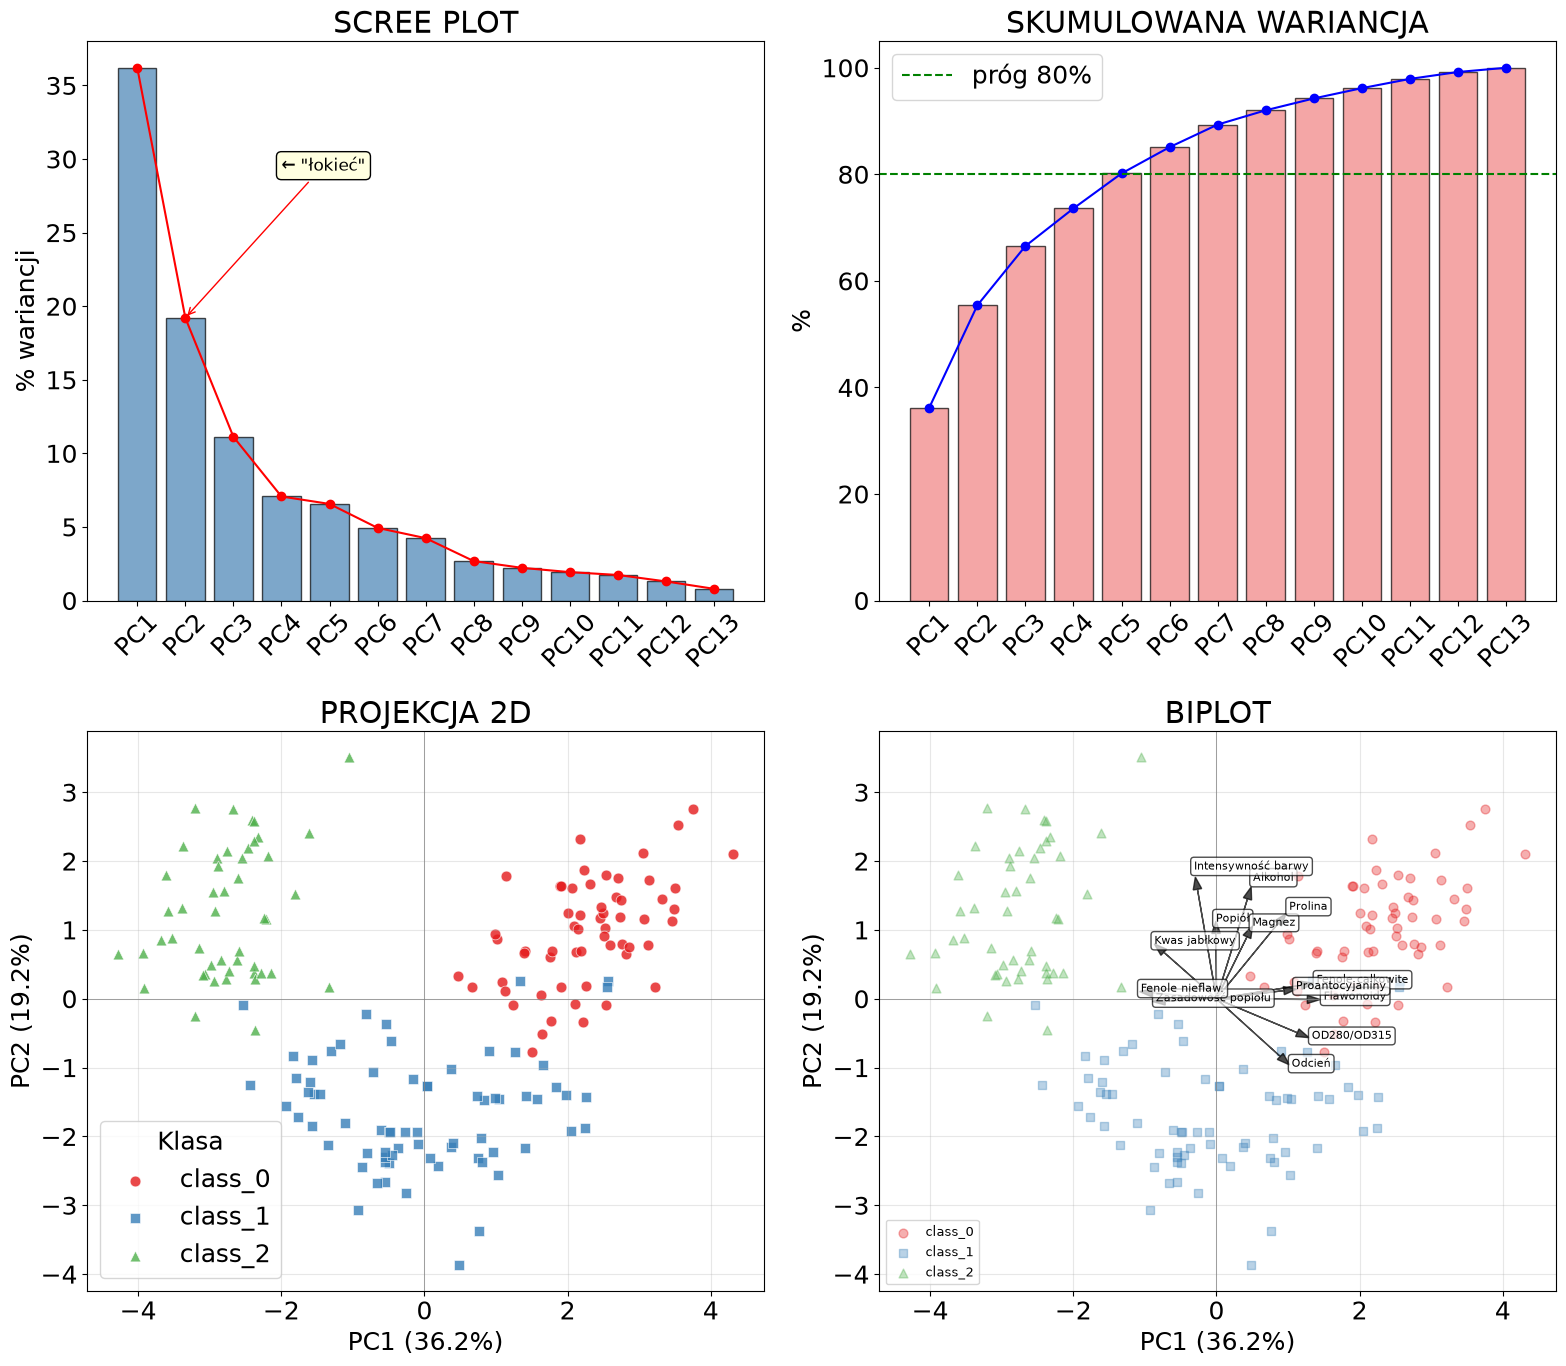

In [12]:
# Część 3 — Wizualizacje: scree plot, projekcja 2D, biplot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
pcs = [f'PC{i+1}' for i in range(len(war))]
kolory = ['#e41a1c', '#377eb8', '#4daf4a']
mk = ['o', 's', '^']

# 3.1 Scree plot z zaznaczonym "łokciem"
ax1 = axes[0, 0]
ax1.bar(pcs, war, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pcs, war, 'ro-')
ax1.set_title('SCREE PLOT'); ax1.set_ylabel('% wariancji')
ax1.tick_params(axis='x', rotation=45)
ax1.annotate('← "łokieć"', xy=(1, war[1]), xytext=(3, war[1] + 10),
             fontsize=12, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Skumulowana wariancja z progiem 80%
ax2 = axes[0, 1]
ax2.bar(pcs, cum, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.plot(pcs, cum, 'bo-')
ax2.axhline(80, color='green', ls='--', label='próg 80%')
ax2.set_title('SKUMULOWANA WARIANCJA'); ax2.set_ylabel('%'); ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# 3.2 Projekcja 2D (PC1 vs PC2) z kolorami klas
ax3 = axes[1, 0]
for i, (kl, ko, m) in enumerate(zip(klasy, kolory, mk)):
    mask = yw == i
    ax3.scatter(Xw_pca[mask, 0], Xw_pca[mask, 1], c=ko, marker=m, s=60,
                label=kl, alpha=0.8, edgecolor='white', linewidth=0.5)
ax3.set_xlabel(f'PC1 ({war[0]:.1f}%)'); ax3.set_ylabel(f'PC2 ({war[1]:.1f}%)')
ax3.set_title('PROJEKCJA 2D'); ax3.legend(title='Klasa'); ax3.grid(alpha=0.3)
ax3.axhline(0, color='gray', lw=0.5); ax3.axvline(0, color='gray', lw=0.5)

# 3.3 Biplot: punkty danych + wektory cech
ax4 = axes[1, 1]
for i, (kl, ko, m) in enumerate(zip(klasy, kolory, mk)):
    mask = yw == i
    ax4.scatter(Xw_pca[mask, 0], Xw_pca[mask, 1], c=ko, marker=m, s=40, alpha=0.35, label=kl)
scale = 3
for i, nz in enumerate(cechy_pl):
    ax4.arrow(0, 0, pca.components_[0, i] * scale, pca.components_[1, i] * scale,
              head_width=0.12, color='black', alpha=0.7)
    ax4.text(pca.components_[0, i] * scale * 1.18, pca.components_[1, i] * scale * 1.18,
             nz, fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax4.set_xlabel(f'PC1 ({war[0]:.1f}%)'); ax4.set_ylabel(f'PC2 ({war[1]:.1f}%)')
ax4.set_title('BIPLOT'); ax4.legend(loc='lower left', fontsize=9); ax4.grid(alpha=0.3)
ax4.axhline(0, color='gray', lw=0.5); ax4.axvline(0, color='gray', lw=0.5)

plt.tight_layout(); plt.show()

In [13]:
# Część 4 — Interpretacja: ładunki dla PC1 i PC2
loadings = pd.DataFrame(pca.components_[:2].T, index=cechy_pl, columns=['PC1', 'PC2'])
print("Ładunki (loadings) cech dla PC1 i PC2:")
display(loadings.round(3))

print("Cechy dominujące w PC1 (wg |ładunku|):")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5).round(3))
print("\nCechy dominujące w PC2 (wg |ładunku|):")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5).round(3))

# Jakość separacji klas w 2D — prosta miara: klasyfikator na PC1,PC2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
acc = cross_val_score(LogisticRegression(max_iter=1000), Xw_pca[:, :2], yw, cv=5).mean()
print(f"\nSeparacja klas w 2D (dokładność 5-CV reg. log. na PC1,PC2): {acc*100:.1f}%")

Ładunki (loadings) cech dla PC1 i PC2:


,PC1,PC2
Alkohol,0.144,0.484
Kwas jabłkowy,-0.245,0.225
Popiół,-0.002,0.316
Zasadowość popiołu,-0.239,-0.011
Magnez,0.142,0.300
Fenole całkowite,0.395,0.065
Flawonoidy,0.423,-0.003
Fenole nieflaw.,-0.299,0.029
Proantocyjaniny,0.313,0.039
Intensywność barwy,-0.089,0.530


Cechy dominujące w PC1 (wg |ładunku|):
Flawonoidy          0.423
Fenole całkowite    0.395
OD280/OD315         0.376
Proantocyjaniny     0.313
Fenole nieflaw.     0.299
Name: PC1, dtype: float64

Cechy dominujące w PC2 (wg |ładunku|):
Intensywność barwy    0.530
Alkohol               0.484
Prolina               0.365
Popiół                0.316
Magnez                0.300
Name: PC2, dtype: float64

Separacja klas w 2D (dokładność 5-CV reg. log. na PC1,PC2): 95.5%


In [14]:
# Porównanie: PCA BEZ standaryzacji — która cecha zdominowała analizę?
pca_raw = PCA().fit(Xw)
war_raw = pca_raw.explained_variance_ratio_ * 100
dom_idx = int(np.argmax(np.abs(pca_raw.components_[0])))

print(f"BEZ standaryzacji PC1 wyjaśnia aż {war_raw[0]:.1f}% wariancji.")
print("Ładunki PC1 (bez standaryzacji):")
print(pd.Series(pca_raw.components_[0], index=cechy_pl).round(3).sort_values(key=abs, ascending=False).head(4))
print(f"\n→ Analizę zdominowała cecha '{cechy_pl[dom_idx]}' (ładunek ≈ {pca_raw.components_[0][dom_idx]:.3f}).")
print("  Ma ona wartości rzędu setek, więc jej wariancja przytłacza pozostałe cechy.")
print("  To dowód, dlaczego standaryzacja przed PCA jest konieczna.")

BEZ standaryzacji PC1 wyjaśnia aż 99.8% wariancji.
Ładunki PC1 (bez standaryzacji):
Prolina               1.000
Magnez                0.018
Zasadowość popiołu   -0.005
Flawonoidy            0.002
dtype: float64

→ Analizę zdominowała cecha 'Prolina' (ładunek ≈ 1.000).
  Ma ona wartości rzędu setek, więc jej wariancja przytłacza pozostałe cechy.
  To dowód, dlaczego standaryzacja przed PCA jest konieczna.


## Część 4 — Odpowiedzi (interpretacja)

- **Ile składowych dla ≥80% wariancji?** → **5 składowych** (skumulowana 80.2%).
  PC1+PC2 dają tylko 55.4%, więc do 2D redukcji tracimy sporo wariancji — ale do *wizualizacji* wystarcza.

- **Które cechy dominują w PC1?** → **Flawonoidy, Fenole całkowite, OD280/OD315, Proantocyjaniny**
  (dodatkowo fenole nieflaw.). PC1 reprezentuje więc **ogólne bogactwo związków fenolowych/polifenoli**
  wina — to główna oś różnicująca próbki.

- **Które cechy dominują w PC2?** → **Intensywność barwy, Alkohol, Prolina, Popiół** — oś związana
  z „mocą/ciałem" wina (kolor + alkohol), niezależna od profilu fenolowego.

- **Czy klasy są dobrze separowalne w 2D?** → **Tak, bardzo dobrze** — prosty klasyfikator na PC1+PC2
  osiąga ~**95.5%** dokładności (5-CV). Na wykresie 2D trzy odmiany tworzą wyraźnie rozdzielone skupiska.

- **Która cecha zdominowała analizę BEZ standaryzacji?** → **Prolina**. Bez standaryzacji PC1
  wyjaśnia 99.8% wariancji, a jego ładunek to niemal wyłącznie Prolina (≈1.0). Powód: Prolina ma
  wartości rzędu setek (aminokwas, µg), a np. Odcień ~1. PCA maksymalizuje wariancję, więc „wygrywa"
  cecha o największej **skali**, a nie o największej informacyjności. **Standaryzacja wyrównuje wpływ
  cech** i dopiero wtedy PCA odkrywa prawdziwą strukturę (grupy fenolowe vs barwa/alkohol).